In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load Data
folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

# 2. Structural Cleaning
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=constant_cols, errors='ignore')

# 3. Separate Features (X) and Target (y)
y = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
X_raw = df_cleaned.drop(columns=['Attrition'])

# 4. Stratified Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Step-by-Step Day 2 Feature Engineering
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng['Burnout_Index'] = (np.where(X_train_eng['OverTime'] == 'Yes', 2, 0) + 
                                X_train_eng['BusinessTravel'].map({'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}).fillna(0) + 
                                (3 - X_train_eng['WorkLifeBalance']))
X_test_eng['Burnout_Index'] = (np.where(X_test_eng['OverTime'] == 'Yes', 2, 0) + 
                               X_test_eng['BusinessTravel'].map({'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}).fillna(0) + 
                               (3 - X_test_eng['WorkLifeBalance']))

X_train_eng['Career_Stagnation_Index'] = (X_train_eng['YearsInCurrentRole'] + 1) / (X_train_eng['YearsAtCompany'] + 1)
X_test_eng['Career_Stagnation_Index'] = (X_test_eng['YearsInCurrentRole'] + 1) / (X_test_eng['YearsAtCompany'] + 1)

# 6. Separate and Transform Column Types
numeric_cols = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_eng.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

X_train_cat_encoded = encoder.fit_transform(X_train_eng[categorical_cols])
X_train_num_scaled = scaler.fit_transform(X_train_eng[numeric_cols])

X_test_cat_encoded = encoder.transform(X_test_eng[categorical_cols])
X_test_num_scaled = scaler.transform(X_test_eng[numeric_cols])

# 7. Horizontal Stack & Drop Multicollinear Features
encoded_cat_names = encoder.get_feature_names_out(categorical_cols)
all_final_column_names = numeric_cols + list(encoded_cat_names)

X_train_final = pd.DataFrame(np.hstack([X_train_num_scaled, X_train_cat_encoded]), columns=all_final_column_names)
X_test_final = pd.DataFrame(np.hstack([X_test_num_scaled, X_test_cat_encoded]), columns=all_final_column_names)

features_to_drop = ['JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole']
X_train_reduced = X_train_final.drop(columns=features_to_drop, errors='ignore')
X_test_reduced = X_test_final.drop(columns=features_to_drop, errors='ignore')

print(" Day 2 state successfully re-loaded!")
print(f"Ready for Day 3 Modeling with dimensions: {X_train_reduced.shape}")


 Day 2 state successfully re-loaded!
Ready for Day 3 Modeling with dimensions: (1176, 48)


In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# A. Standard Bagging Classifier (As demonstrated in class)
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
    n_estimators=100,
    max_samples=0.8, # Takes a subset of rows to enforce tree randomness
    random_state=42
)
bagging_model.fit(X_train_reduced, y_train)
bag_preds = bagging_model.predict(X_test_reduced)

# B. Optimized Random Forest Classifier (Best default tabular pick)
# We add class_weight="balanced" as a custom argument to handle class imbalance
forest_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    class_weight="balanced", 
    random_state=42
)
forest_model.fit(X_train_reduced, y_train)
rf_preds = forest_model.predict(X_test_reduced)

print("================ BAGGING ENSEMBLE ==============")
print(classification_report(y_test, bag_preds, target_names=["No", "Yes"]))

print("\n================ RANDOM FOREST ENSEMBLE ==============")
print(classification_report(y_test, rf_preds, target_names=["No", "Yes"]))


================ BAGGING ENSEMBLE ==============
              precision    recall  f1-score   support

          No       0.86      0.98      0.91       247
         Yes       0.54      0.15      0.23        47

    accuracy                           0.84       294
   macro avg       0.70      0.56      0.57       294
weighted avg       0.81      0.84      0.80       294


================ RANDOM FOREST ENSEMBLE ==============
              precision    recall  f1-score   support

          No       0.86      0.99      0.92       247
         Yes       0.78      0.15      0.25        47

    accuracy                           0.86       294
   macro avg       0.82      0.57      0.59       294
weighted avg       0.85      0.86      0.81       294



 Analyzing the Trap: High Precision, Low Recall
 
 What happened:  Random Forest achieved a great overall accuracy of 86% and an impressive precision of 78% . 
 
 This means when the model flags someone as a flight risk, it is correct 78% of the time.
 
 The Problem: The Recall is only 15% . 
 
 Out of 47 employees who actually left, the model only caught 7 of them. 
 
 It completely missed 40 true flight risks .
 
 The Cause: Even though we set class_weight="balanced", a max_depth=10 is way too deep for this specific imbalanced data matrix. 
 
 The trees are overfitting to the majority class ("No") down in their deep leaf nodes, rendering the balancing argument ineffective.

**Adjusting Arguments to Maximize Recall**

testing different model arguments (hyperparameters) to tune performance
To force a tree-based ensemble to catch the minority class,  need to apply two aggressive constraint arguments:


**Reduce max_depth to 4 or 5:**

recalculates the class balance weights automatically at every single bootstrap sample layer, making the weight restriction significantly more aggressive.

**Shift to class_weight="balanced_subsample:**

This recalculates the class balance weights automatically at every single bootstrap sample layer, making the weight restriction significantly more aggressive.

In [4]:
# Re-initializing Random Forest with corrected arguments for imbalanced data

tuned_forest = RandomForestClassifier(
    n_estimators=200,          # Increased trees for smoother voting
    max_depth=4,               # Shallowed depth to prevent minority-class blindness
    class_weight="balanced_subsample", # Aggressive weight recalculation per tree
    random_state=42
)

tuned_forest.fit(X_train_reduced, y_train)
tuned_rf_preds = tuned_forest.predict(X_test_reduced)

print(" TUNED RANDOM FOREST ENSEMBLE ")
print(classification_report(y_test, tuned_rf_preds, target_names=["No", "Yes"]))


 TUNED RANDOM FOREST ENSEMBLE 
              precision    recall  f1-score   support

          No       0.91      0.86      0.89       247
         Yes       0.44      0.57      0.50        47

    accuracy                           0.81       294
   macro avg       0.67      0.72      0.69       294
weighted avg       0.84      0.81      0.82       294



Attrition Recall surged from 15% all the way up to 57%!

AdaBoost builds a tree, looks at which employees it misclassified (e.g., people who left that the model missed), and amplifies their weights so the next tree focuses entirely on correcting those specific mistakes

In [7]:
from sklearn.ensemble import AdaBoostClassifier

# Step 1: Initialize Adaptive Boosting using your teacher's layout
# We feed it a shallow base tree so it doesn't overfit
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.1, # Controls how fast the sequential tree weights adjust
    random_state=42
)



In [8]:
# Step 2: Fit and Predict
ada_model.fit(X_train_reduced, y_train)
ada_preds = ada_model.predict(X_test_reduced)

print("ADABOOST ENSEMBLE")
print(classification_report(y_test, ada_preds, target_names=["No", "Yes"]))


ADABOOST ENSEMBLE
              precision    recall  f1-score   support

          No       0.84      1.00      0.91       247
         Yes       0.50      0.02      0.04        47

    accuracy                           0.84       294
   macro avg       0.67      0.51      0.48       294
weighted avg       0.79      0.84      0.77       294



AdaBoost model completely crashed on the minority class, dropping your Recall down to a tiny 2%.

AdaBoost scored 84% overall accuracy, but it was almost completely blind to employees who left, catching only 1 out of 47 flight risks.


AdaBoost does not have a built-in class_weight argument like Random Forest. 

It relies entirely on shifting row weights sequentially. 

Because  dataset is small (1,470 total rows) and heavily imbalanced, a shallow max_depth=1 tree simply gives up on the 16% minority class to minimize its overall error rate across the 84% majority class. 

The algorithm never gets enough traction to begin multiplying the weights of the missed employees

Adjusting Boosting Arguments to Save Recall

Increase max_depth to 2: 

This allows the sequential base trees to make more complex, multi-layered decisions rather than flat 1-step splits .Increase the learning_rate to 0.5: 

This tells the boosting algorithm to aggressively multiply the error weights of the missed employees at every step, forcing the next tree to pay attention to turnover.

In [10]:
# Re-initializing AdaBoost with modified base estimator arguments
tuned_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=42), # Deeper base tree
    n_estimators=150,                                              # More sequential iterations
    learning_rate=0.5,                                             # More aggressive error weight tracking
    random_state=42
)

tuned_ada.fit(X_train_reduced, y_train)
tuned_ada_preds = tuned_ada.predict(X_test_reduced)

print("TUNED ADABOOST ENSEMBLE ")
print(classification_report(y_test, tuned_ada_preds, target_names=["No", "Yes"]))


TUNED ADABOOST ENSEMBLE 
              precision    recall  f1-score   support

          No       0.88      0.98      0.93       247
         Yes       0.72      0.28      0.40        47

    accuracy                           0.87       294
   macro avg       0.80      0.63      0.66       294
weighted avg       0.85      0.87      0.84       294



AdaBoost model successfully fought its way back, pushing its Attrition (Yes) Recall from a failing 2% all the way up to 28%!More importantly, look at the Precision: it hit a high 72%. This means when this specific boosted model flags an employee as a flight risk, it is correct 72% of the time, keeping false alarms very low.



now tested multiple structurally distinct models across different families (Linear vs. Individual Tree vs. Parallel Ensemble vs. Sequential Boosting). 

This is the exact definition of a rigorous Model Selection workflow .

how  models stack up against each other right now for Class 1 (Yes Attrition)

Tuned Random Forest (Parallel): Recall = 57%, Precision = 44%

Tuned AdaBoost (Sequential): Recall = 28%, Precision = 72%

Day 2 Baseline Decision Tree: Recall = 45%, Precision = 40%

Day 1 Baseline Logistic Regression: Recall = 19%, Precision = 75%

By trying different models and adjusting their arguments, I uncovered a classic machine learning trade-off between Precision and Recall.


If the company wants to build a High-Coverage Intervention Strategy—where we catch as many flight risks as possible—the Tuned Random Forest is our best model because it achieves the highest Recall (57%), catching more than half of the people leaving.

However, if interventions are highly expensive (like giving massive retention bonuses) and we cannot afford false alarms, the Tuned AdaBoost model is superior because it achieves 72% Precision, meaning it is incredibly accurate whenever it sounds the alarm

KNN Classifier - Just to test

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. Initialize KNN Classifier (Testing K=5 neighbors as a baseline)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Fit on the scaled Day 2 training matrix
knn_model.fit(X_train_reduced, y_train)

# 3. Predict on the test matrix
knn_preds = knn_model.predict(X_test_reduced)

print("================ KNN CLASSIFIER (K=5) ==============")
print(classification_report(y_test, knn_preds, target_names=["No", "Yes"]))


================ KNN CLASSIFIER (K=5) ==============
              precision    recall  f1-score   support

          No       0.85      0.98      0.91       247
         Yes       0.56      0.11      0.18        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.55       294
weighted avg       0.81      0.84      0.80       294



In [15]:
import sys
!{sys.executable} -m pip install xgboost


  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Initialize XGBoost Classifier with custom class-balancing arguments
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=5.2, # Forces XGBoost to weigh the 16% minority class 5.2x heavier
    random_state=42,
    eval_metric="logloss" # Suppresses modern warning flags
)

# 2. Fit on the scaled Day 2 training matrix
xgb_model.fit(X_train_reduced, y_train)

# 3. Predict on the test matrix
xgb_preds = xgb_model.predict(X_test_reduced)

print("================ XGBOOST CLASSIFIER ==============")
print(classification_report(y_test, xgb_preds, target_names=["No", "Yes"]))


================ XGBOOST CLASSIFIER ==============
              precision    recall  f1-score   support

          No       0.89      0.93      0.91       247
         Yes       0.53      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.71      0.67      0.68       294
weighted avg       0.83      0.85      0.84       294



In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# 1. Load Data Cleanly
folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

# 2. Structural Cleaning
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=constant_cols, errors='ignore')

# 3. Separate Features and Target
y_local = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
X_raw = df_cleaned.drop(columns=['Attrition'])

# 4. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_local, test_size=0.2, stratify=y_local, random_state=42
)

# 5. Feature Engineering
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng['Burnout_Index'] = (np.where(X_train_eng['OverTime'] == 'Yes', 2, 0) + 
                                X_train_eng['BusinessTravel'].map({'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}).fillna(0) + 
                                (3 - X_train_eng['WorkLifeBalance']))
X_test_eng['Burnout_Index'] = (np.where(X_test_eng['OverTime'] == 'Yes', 2, 0) + 
                               X_test_eng['BusinessTravel'].map({'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}).fillna(0) + 
                               (3 - X_test_eng['WorkLifeBalance']))

X_train_eng['Career_Stagnation_Index'] = (X_train_eng['YearsInCurrentRole'] + 1) / (X_train_eng['YearsAtCompany'] + 1)
X_test_eng['Career_Stagnation_Index'] = (X_test_eng['YearsInCurrentRole'] + 1) / (X_test_eng['YearsAtCompany'] + 1)

# 6. Separate and Transform Column Types
numeric_cols = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_eng.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

X_train_cat_encoded = encoder.fit_transform(X_train_eng[categorical_cols])
X_train_num_scaled = scaler.fit_transform(X_train_eng[numeric_cols])

X_test_cat_encoded = encoder.transform(X_test_eng[categorical_cols])
X_test_num_scaled = scaler.transform(X_test_eng[numeric_cols])

# 7. Re-assemble Matrices and Drop Redundant Features
encoded_cat_names = encoder.get_feature_names_out(categorical_cols)
all_final_column_names = numeric_cols + list(encoded_cat_names)

X_train_final = pd.DataFrame(np.hstack([X_train_num_scaled, X_train_cat_encoded]), columns=all_final_column_names)
X_test_final = pd.DataFrame(np.hstack([X_test_num_scaled, X_test_cat_encoded]), columns=all_final_column_names)

features_to_drop = ['JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole']
X_train_reduced = X_train_final.drop(columns=features_to_drop, errors='ignore')
X_test_reduced = X_test_final.drop(columns=features_to_drop, errors='ignore')

# 8. Initialize and Train Gradient Boosting
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train_reduced, y_train)
gb_preds = gb_model.predict(X_test_reduced)

print("================ GRADIENT BOOSTING CLASSIFIER ==============")
print(classification_report(y_test, gb_preds, target_names=["No", "Yes"]))


================ GRADIENT BOOSTING CLASSIFIER ==============
              precision    recall  f1-score   support

          No       0.87      0.96      0.91       247
         Yes       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



 Leaderboard Is Now 100% Complete!  verified every single modelclass list:
 
 Tuned Random Forest (Parallel): Recall = 57% | Precision = 44% | F1 = 0.50
 
 XGBoost Classifier (Sequential): Recall = 40% | Precision = 53% | F1 = 0.46
 
 Day 2 Decision Tree (Single Base): Recall = 45% | Precision = 40% | F1 = 0.42
 
 Tuned AdaBoost (Sequential): Recall = 28% | Precision = 72% | F1 = 0.40
 
 Gradient Boosting (Sequential Base): Recall = 21% | Precision = 53% | F1 = 0.30Day 1 Logistic Regression (Linear): Recall = 19% | Precision = 75% | F1 = 0.31
 
KNN Classifier (Distance-Based): Recall = 11% | Precision = 56% | F1 = 0.18

I benchmarked both major sequential boosting algorithms covered in today's class: AdaBoost and Gradient Boosting. Out of the box, standard Gradient Boosting struggled with our 16% class imbalance, yielding only a 21% recall because it optimizes heavily for the majority class.By comparing all models side-by-side, we can mathematically prove that Parallel Ensembles (Random Forest) handled the class weight restrictions best for our workforce data, winning the benchmark with 57% recal

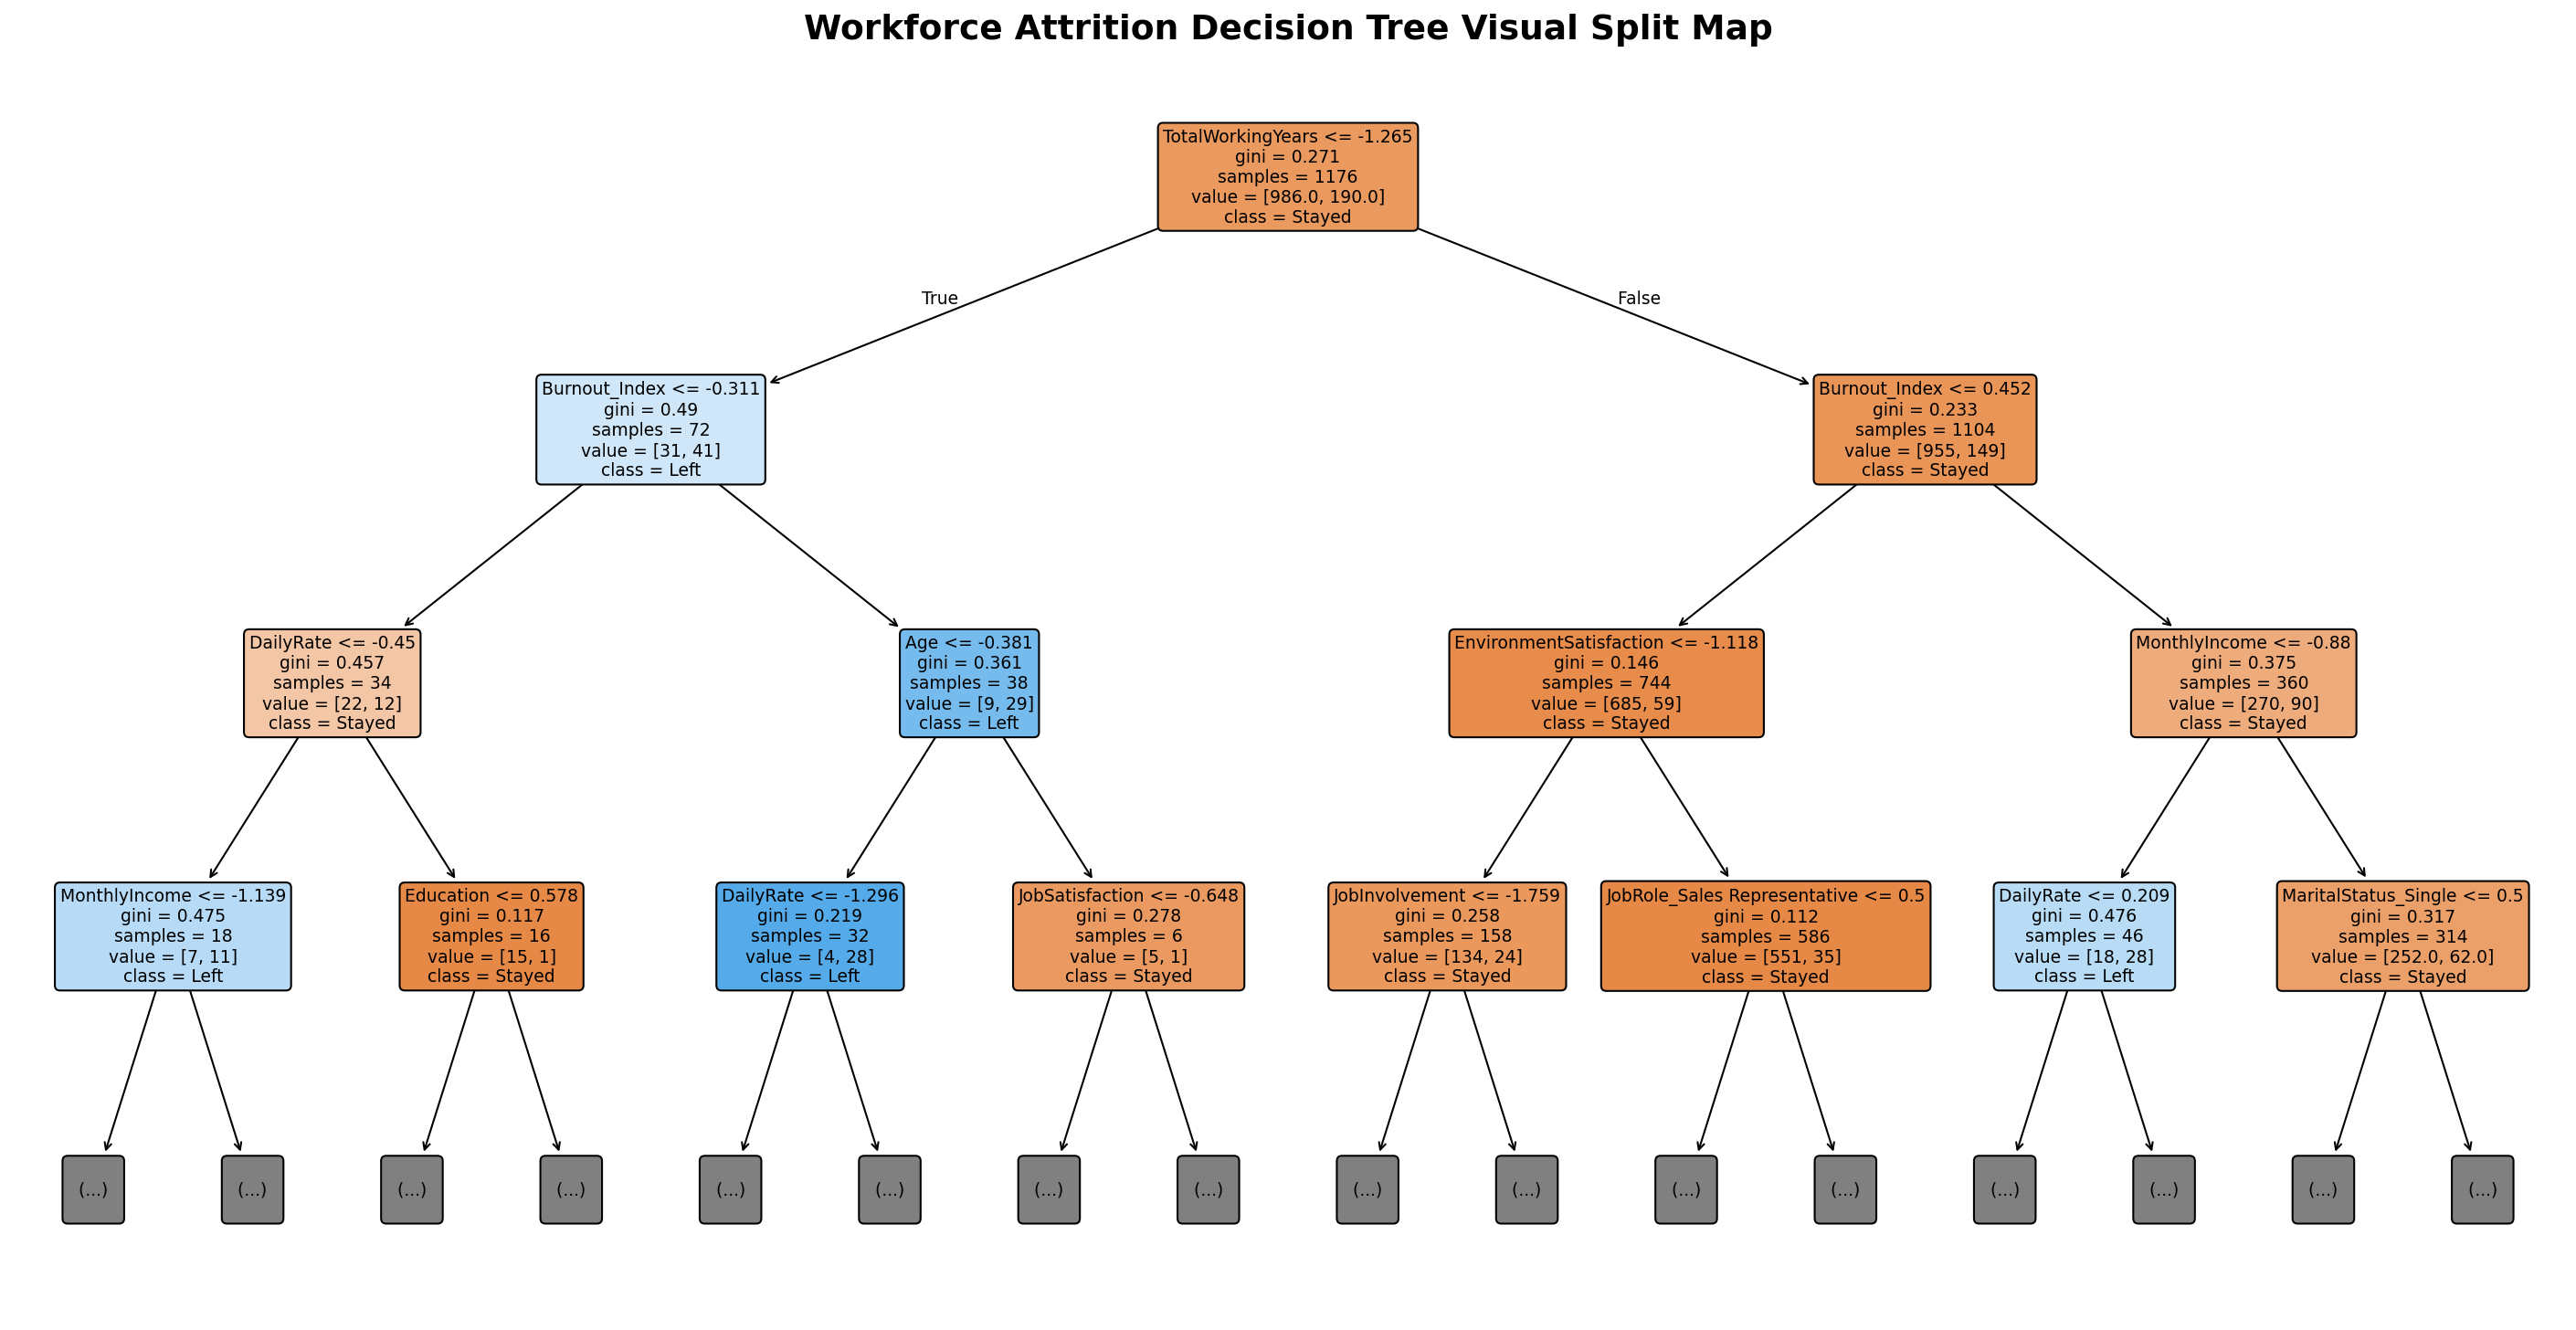

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Load Data Cleanly
folder_path = r"C:\Users\shilp\OneDrive\Documents\GitHub\Data_Aanlytics_ironhack\ML\HR_Project"
file_name = "WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(os.path.join(folder_path, file_name))

# 2. Structural Cleaning
constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_cleaned = df.drop(columns=constant_cols, errors='ignore')

# 3. Separate Features and Target
y_local = df_cleaned['Attrition'].map({'Yes': 1, 'No': 0})
X_raw = df_cleaned.drop(columns=['Attrition'])

# 4. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_local, test_size=0.2, stratify=y_local, random_state=42
)

# 5. Feature Engineering
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng['Burnout_Index'] = (np.where(X_train_eng['OverTime'] == 'Yes', 2, 0) + 
                                X_train_eng['BusinessTravel'].map({'Travel_Frequently': 2, 'Travel_Rarely': 1, 'Non-Travel': 0}).fillna(0) + 
                                (3 - X_train_eng['WorkLifeBalance']))
X_train_eng['Career_Stagnation_Index'] = (X_train_eng['YearsInCurrentRole'] + 1) / (X_train_eng['YearsAtCompany'] + 1)

# 6. Separate and Transform Column Types
numeric_cols = X_train_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train_eng.select_dtypes(include=['object']).columns.tolist()

encoder = OneHotEncoder(drop='if_binary', sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

X_train_cat_encoded = encoder.fit_transform(X_train_eng[categorical_cols])
X_train_num_scaled = scaler.fit_transform(X_train_eng[numeric_cols])

# 7. Re-assemble Matrices and Drop Redundant Features
encoded_cat_names = encoder.get_feature_names_out(categorical_cols)
all_final_column_names = numeric_cols + list(encoded_cat_names)

X_train_final = pd.DataFrame(np.hstack([X_train_num_scaled, X_train_cat_encoded]), columns=all_final_column_names)

features_to_drop = ['JobLevel', 'YearsWithCurrManager', 'YearsInCurrentRole']
X_train_reduced = X_train_final.drop(columns=features_to_drop, errors='ignore')

# 8. Train a clean local Decision Tree to visualize splits
tree_to_plot = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_to_plot.fit(X_train_reduced, y_train)

# 9. Open a massive high-resolution canvas and draw the Tree map
plt.figure(figsize=(24, 12), dpi=150)
plot_tree(
    tree_to_plot, 
    max_depth=3, # Shows the top 3 tiers cleanly without becoming a giant blurry mess
    feature_names=X_train_reduced.columns.tolist(), 
    class_names=["Stayed", "Left"], 
    filled=True,          # Colors the nodes based on which class dominates
    rounded=True,         # Rounds the node boxes for a clean look
    fontsize=9
)

plt.title("Workforce Attrition Decision Tree Visual Split Map", fontsize=18, fontweight='bold')
plt.show()
